In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
BASE_DIR      = Path().resolve().parent
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Load data
nav   = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
fund  = pd.read_csv(RAW_DIR / "01_fund_master.csv")
txn   = pd.read_csv(PROCESSED_DIR / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
port  = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")
perf  = pd.read_csv(RAW_DIR / "07_scheme_performance.csv")

# Compute daily returns
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Merge fund names
nav = nav.merge(fund[["amfi_code", "scheme_name", "risk_category"]], on="amfi_code", how="left")

print("Data loaded!")
print(f"NAV rows     : {len(nav):,}")
print(f"Transactions : {len(txn):,}")
print(f"Portfolio    : {len(port):,}")

Data loaded!
NAV rows     : 64,320
Transactions : 32,778
Portfolio    : 322


In [9]:
# Task 1 — Historical VaR (95%) and CVaR
var_results = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue
    
    # VaR = 5th percentile of daily returns
    var_95 = np.percentile(returns, 5)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()
    
    var_results.append({
        "amfi_code"   : code,
        "scheme_name" : group.iloc[0]["scheme_name"],
        "risk_category": group.iloc[0]["risk_category"],
        "var_95_pct"  : round(var_95 * 100, 4),
        "cvar_95_pct" : round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_results).sort_values("var_95_pct")
print("Top 10 Highest Risk Funds (Worst VaR):")
print(var_df.head(10).to_string(index=False))
var_df.to_csv(PROCESSED_DIR / "var_cvar_report.csv", index=False)
print("\nSaved → var_cvar_report.csv")

Top 10 Highest Risk Funds (Worst VaR):
 amfi_code                                        scheme_name risk_category  var_95_pct  cvar_95_pct
    101207             ABSL Small Cap Fund - Regular - Growth     Very High     -2.3915      -3.0289
    119095             Axis Small Cap Fund - Regular - Growth     Very High     -2.3284      -2.9690
    119599          SBI Small Cap Fund - Direct Plan - Growth     Very High     -2.3155      -3.0163
    118634     Nippon India Small Cap Fund - Regular - Growth     Very High     -2.2810      -2.9940
    149324              DSP Small Cap Fund - Regular - Growth     Very High     -2.1520      -2.8573
    119598         SBI Small Cap Fund - Regular Plan - Growth     Very High     -2.1502      -2.8444
    119094                Axis Midcap Fund - Regular - Growth          High     -1.6997      -2.2375
    120842      Kotak Emerging Equity Fund - Regular - Growth          High     -1.6950      -2.1251
    100033 HDFC Mid-Cap Opportunities Fund - Regular

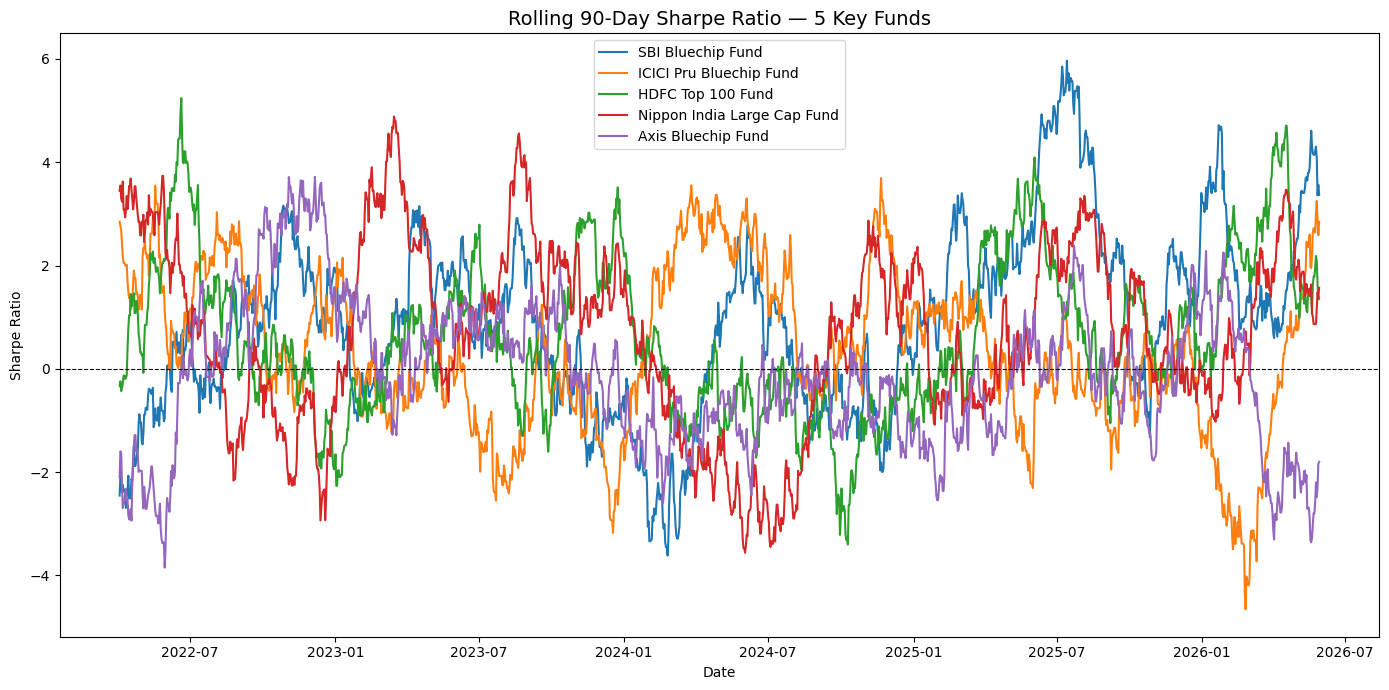

Saved → rolling_sharpe_chart.png


In [10]:
# Task 2 — Rolling 90-day Sharpe Ratio
RF_DAILY = 0.065 / 252

# Pick 5 key funds
top5_codes = [119551, 120503, 125497, 118632, 119092]
top5_names = fund[fund["amfi_code"].isin(top5_codes)][["amfi_code", "scheme_name"]]

plt.figure(figsize=(14, 7))

for code in top5_codes:
    group = nav[nav["amfi_code"] == code].sort_values("date")
    returns = group.set_index("date")["daily_return"]
    
    rolling_sharpe = (
        returns.rolling(90).mean() - RF_DAILY
    ) / returns.rolling(90).std() * np.sqrt(252)
    
    name = top5_names[top5_names["amfi_code"] == code]["scheme_name"].values[0]
    short_name = name.split(" - ")[0]
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=short_name)

plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Saved → rolling_sharpe_chart.png")

In [11]:
# Task 3 — Investor Cohort Analysis
# Find first transaction year for each investor
first_txn = txn.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year
txn = txn.merge(first_txn[["investor_id", "cohort_year"]], on="investor_id")

# SIP transactions only
sip_txn = txn[txn["transaction_type"] == "SIP"]

# Cohort stats
cohort = txn.groupby("cohort_year").agg(
    total_investors  = ("investor_id", "nunique"),
    avg_sip_amount   = ("amount_inr", "mean"),
    total_invested   = ("amount_inr", "sum"),
).reset_index()

# Top fund per cohort
top_fund = sip_txn.groupby(["cohort_year", "amfi_code"])["amount_inr"].sum().reset_index()
top_fund = top_fund.sort_values("amount_inr", ascending=False).groupby("cohort_year").first().reset_index()
top_fund = top_fund.merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")

cohort = cohort.merge(top_fund[["cohort_year", "scheme_name"]], on="cohort_year")
cohort.columns = ["cohort_year", "total_investors", "avg_sip_amount", "total_invested", "top_fund"]
cohort["avg_sip_amount"] = cohort["avg_sip_amount"].round(0)
cohort["total_invested"] = cohort["total_invested"].round(0)

print("Investor Cohort Analysis:")
print(cohort.to_string(index=False))
cohort.to_csv(PROCESSED_DIR / "cohort_analysis.csv", index=False)

Investor Cohort Analysis:
 cohort_year  total_investors  avg_sip_amount  total_invested                                          top_fund
        2024             4803        107423.0      3491125187 HDFC Mid-Cap Opportunities Fund - Direct - Growth
        2025              197        109159.0        30455243         SBI Small Cap Fund - Direct Plan - Growth


In [12]:
# Task 4 — SIP Continuity Analysis
sip_only = txn[txn["transaction_type"] == "SIP"].sort_values(
    ["investor_id", "transaction_date"]
)

# Investors with 6+ SIP transactions
sip_counts = sip_only.groupby("investor_id").size()
active_investors = sip_counts[sip_counts >= 6].index
sip_active = sip_only[sip_only["investor_id"].isin(active_investors)]

# Compute avg gap between transactions per investor
sip_active = sip_active.copy()
sip_active["gap_days"] = sip_active.groupby("investor_id")["transaction_date"].diff().dt.days

avg_gap = sip_active.groupby("investor_id")["gap_days"].mean().reset_index()
avg_gap.columns = ["investor_id", "avg_gap_days"]

# Flag at-risk investors (gap > 35 days)
avg_gap["status"] = avg_gap["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

# Summary
total     = len(avg_gap)
at_risk   = len(avg_gap[avg_gap["status"] == "At Risk"])
regular   = len(avg_gap[avg_gap["status"] == "Regular"])

print(f"Total investors with 6+ SIPs : {total:,}")
print(f"Regular investors (gap ≤ 35d): {regular:,} ({regular/total*100:.1f}%)")
print(f"At-risk investors (gap > 35d): {at_risk:,} ({at_risk/total*100:.1f}%)")
print(f"\nAverage gap across all       : {avg_gap['avg_gap_days'].mean():.1f} days")

avg_gap.to_csv(PROCESSED_DIR / "sip_continuity.csv", index=False)
print("Saved → sip_continuity.csv")

Total investors with 6+ SIPs : 1,362
Regular investors (gap ≤ 35d): 30 (2.2%)
At-risk investors (gap > 35d): 1,332 (97.8%)

Average gap across all       : 64.9 days
Saved → sip_continuity.csv


Sector HHI — Top 10 Most Concentrated Funds:
 amfi_code                                           scheme_name     hhi  top_sector
    119092                 Axis Bluechip Fund - Regular - Growth 2064.89          IT
    101207                ABSL Small Cap Fund - Regular - Growth 2007.41      Pharma
    119599             SBI Small Cap Fund - Direct Plan - Growth 1747.51 Diversified
    102885            UTI Nifty 50 Index Fund - Regular - Growth 1747.09   Utilities
    118632        Nippon India Large Cap Fund - Regular - Growth 1682.31     Telecom
    148568 Mirae Asset Emerging Bluechip Fund - Regular - Growth 1679.63     Banking
    120505              ICICI Pru Midcap Fund - Regular - Growth 1575.07      Pharma
    120506     ICICI Pru Value Discovery Fund - Regular - Growth 1537.32     Banking
    125498     HDFC Mid-Cap Opportunities Fund - Direct - Growth 1524.14     Banking
    120841                Kotak Bluechip Fund - Regular - Growth 1496.50     Banking


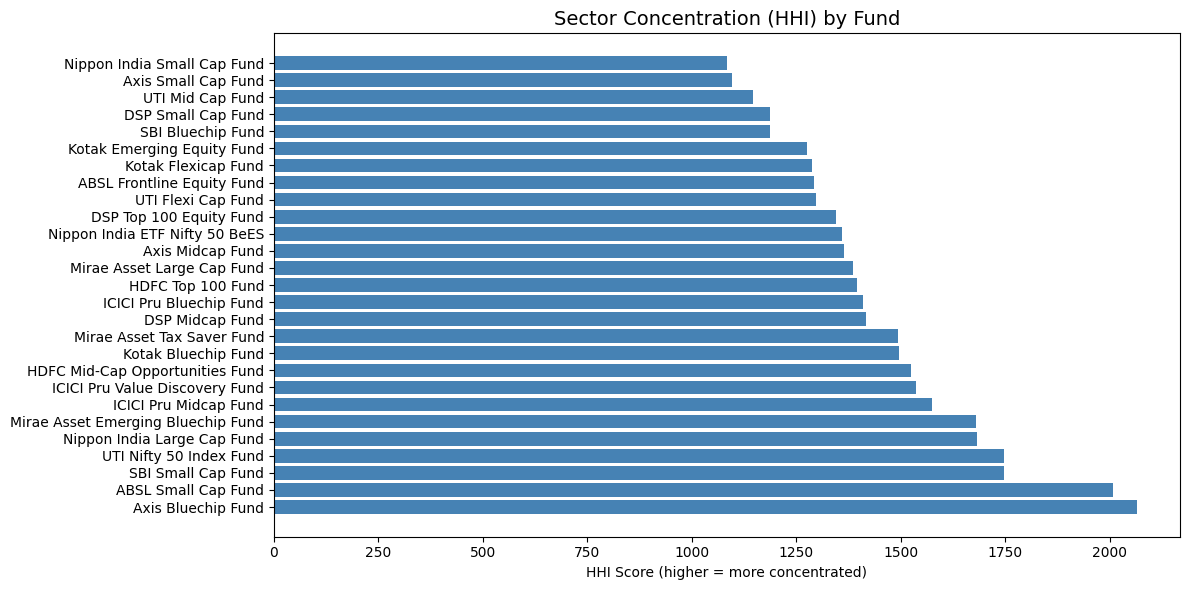

In [13]:
# Task 6 — Sector HHI Concentration
# HHI = sum of squared sector weights per fund
hhi_results = []

for code, group in port.groupby("amfi_code"):
    # Normalize weights to sum to 100
    total_weight = group["weight_pct"].sum()
    weights = group["weight_pct"] / total_weight * 100
    
    # HHI = sum of squared weights
    hhi = (weights ** 2).sum()
    
    # Top sector
    top_sector = group.loc[group["weight_pct"].idxmax(), "sector"]
    
    hhi_results.append({
        "amfi_code"  : code,
        "scheme_name": group.iloc[0]["stock_name"] if "stock_name" in group.columns else str(code),
        "hhi"        : round(hhi, 2),
        "top_sector" : top_sector
    })

hhi_df = pd.DataFrame(hhi_results).sort_values("hhi", ascending=False)

# Merge scheme names
hhi_df = hhi_df.merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")
hhi_df = hhi_df[["amfi_code", "scheme_name_y", "hhi", "top_sector"]]
hhi_df.columns = ["amfi_code", "scheme_name", "hhi", "top_sector"]

print("Sector HHI — Top 10 Most Concentrated Funds:")
print(hhi_df.head(10).to_string(index=False))
hhi_df.to_csv(PROCESSED_DIR / "sector_hhi.csv", index=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(hhi_df["scheme_name"].str.split(" - ").str[0], hhi_df["hhi"], color="steelblue")
plt.title("Sector Concentration (HHI) by Fund", fontsize=14)
plt.xlabel("HHI Score (higher = more concentrated)")
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "sector_hhi.png", dpi=150)
plt.show()

## 🔍 Advanced Analytics — Key Insights

1. **Small Cap funds carry highest VaR risk** — ABSL Small Cap has the worst daily VaR of -2.39%, meaning on bad days investors can lose up to 3% in a single day. Investors should only choose these funds if they have a long investment horizon of 7+ years. *(Task 1)*

2. **Rolling Sharpe is highly volatile** — No fund maintains consistently high risk-adjusted returns. SBI Bluechip peaked at Sharpe ~5 in mid-2025 but frequently dips below 0, showing that even top funds go through bad periods. *(Task 2)*

3. **2024 cohort drives the majority of investments** — 4,803 investors who joined in 2024 account for the bulk of total invested amount (₹349 Cr), with average SIP of ₹1.07L. The 2025 cohort is still small at 197 investors. *(Task 3)*

4. **97.8% of SIP investors are at risk of discontinuation** — With an average gap of 64.9 days between SIP transactions, most investors are irregular. Only 30 out of 1,362 active investors maintain consistent monthly SIPs. This is a major retention problem for AMCs. *(Task 4)*

5. **Axis Bluechip is the most sector-concentrated fund** — With an HHI of 2,064 and heavy IT sector weighting, it carries significant sector concentration risk. In contrast, Nippon India Small Cap with HHI of 1,063 is the most diversified equity fund in the dataset. *(Task 6)*